In [2]:
import sys
sys.path.insert(0, '..')
from model.data import getMyData
from model.embedding import PositionEmbedding, FixedEmbedding, projEmbedding, TimeFeatureEmbedding, DataEmbedding, TokenEmbedding
import torch_ep.embed as epEmbed
import torch
import numpy  as np
import tensorflow as tf

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [ ]:
#TEST My Forecast
DATA_SIZE = 3000 #TTFData.shape[0]
SEQ_LEN = 20
BATCH_SIZE = 32
myDataFct = getMyData(data_size=DATA_SIZE, seq_len=SEQ_LEN,batch_len=BATCH_SIZE)
dataset, datasetVal = myDataFct.get()
myDataFct.display()
btX = (list(enumerate(myDataFct.dataset))[0][1][0])
btY = (list(enumerate(myDataFct.dataset))[0][1][1])
btX_T = torch.from_numpy(btX.numpy())
btY_T = torch.from_numpy(btY.numpy())

In [ ]:
#Position Embedding
#Embedding Torch
posEmb = epEmbed.PositionalEmbedding(512)
d = posEmb(btX_T)
fig = plt.figure(figsize=(18,2))
sns.heatmap(d[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');
#Embedding Keras
KposEmbFct = PositionEmbedding(seq_len=SEQ_LEN,d_model=512)
Kd = KposEmbFct(btX)
fig = plt.figure(figsize=(18,2))
sns.heatmap(Kd, vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');

In [ ]:
btx_Int = torch.randint(0,100,(BATCH_SIZE,SEQ_LEN,1)).long()
print(btx_Int.shape)
C_IN = 4
btx_Int_np = np.random.randint(0,C_IN,size=(BATCH_SIZE,SEQ_LEN,1),dtype=np.int64)
# print(btx_Int[:,:,0].shape)
print(btx_Int_np.shape)
btx_Int = torch.from_numpy(btx_Int_np)
btx_Int_K = tf.convert_to_tensor(btx_Int_np)
print(btx_Int.shape)

In [ ]:
#FixedEmbedding for Time 
#Embedding Torch
posEmb = epEmbed.FixedEmbedding(c_in=C_IN,d_model=512)
print(btx_Int.shape)
d = posEmb(btx_Int[:,:,0])
fig = plt.figure(figsize=(18,2))
sns.heatmap(d[1], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Fixed');
#Embedding Keras
KposEmbFct = FixedEmbedding(c_in=C_IN,d_model=512)
Kd = KposEmbFct(btx_Int_K[:,:,0])
print(Kd.shape)
fig = plt.figure(figsize=(18,2))
sns.heatmap(Kd[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Fixed');

In [ ]:
#Token Embedding for Time 
#Embedding Torch
posEmb = epEmbed.TokenEmbedding(c_in=1,d_model=512)
d = posEmb(btX_T)
fig = plt.figure(figsize=(18,2))
sns.heatmap(d.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Token');
#Embedding Keras
KposEmbFct = projEmbedding(d_model=512, rate=0.15)
Kd = KposEmbFct(btX)
fig = plt.figure(figsize=(18,2))
sns.heatmap(Kd[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Token');

In [ ]:
m = torch.nn.Conv1d(50, 512, 3, stride=1,padding=1, padding_mode='circular')
input = torch.randn(20, 16, 50)
output = m(input.permute(0,2,1)).transpose(1,2)
output.shape

In [3]:
# Get Features from ETTh1
import pandas as pd
import os
import re
root_path = "../../data/"
data_path = "ETTh1.csv"
df_raw = pd.read_csv(os.path.join(root_path,data_path))

SEQ_LEN = 25
BATCH_SIZE = 32

# split = re.compile('-|:| ')
# featuresDate = (df_raw['date'].str.split(split, expand=True)).astype(np.int64).iloc[:,:4]
featuresData = df_raw.iloc[:,1:8].astype(np.float32)

# On ajoute les infos temporelles : mois/jour/joursemain/heure
df_raw['mois'] = df_raw.date.apply(lambda row:int(row[5:7])).astype(np.int64)
df_raw['jour'] = df_raw.date.apply(lambda row:int(row[8:10])).astype(np.int64)
df_raw['heure'] = df_raw.date.apply(lambda row:int(row[11:13])).astype(np.int64)
df_raw['sJour'] = df_raw['date'].astype('datetime64[s]').dt.dayofweek.astype(np.int64)
featuresDate = df_raw[['mois','jour','sJour','heure']].astype(np.int64)
# featuresDate.describe()

# Convert Features to numpy array
featuresData = featuresData.to_numpy()
featuresDate = featuresDate.to_numpy()
# Create a dataset Feature Data
X = np.array([featuresData[i:i+SEQ_LEN] for i in range(0, featuresData.shape[0]-SEQ_LEN)], dtype=np.float32)
Y = np.array([featuresData[i+SEQ_LEN] for i in range(0, featuresData.shape[0]-SEQ_LEN-1)], dtype=np.float32)
Xt = tf.convert_to_tensor(X, dtype=tf.float32)
XT = torch.from_numpy(X)

# Create a dataset : Features Date
X = np.array([featuresDate[i:i+SEQ_LEN] for i in range(0, featuresDate.shape[0]-SEQ_LEN)], dtype=np.float32)
Y = np.array([featuresDate[i+SEQ_LEN] for i in range(0, featuresDate.shape[0]-SEQ_LEN-1)], dtype=np.float32)
XtDate = tf.convert_to_tensor(X, dtype=tf.float32)
XTDate = torch.from_numpy(X)

2024-08-31 19:13:42.783740: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-08-31 19:13:42.783762: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-08-31 19:13:42.783767: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-08-31 19:13:42.783931: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-08-31 19:13:42.784083: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


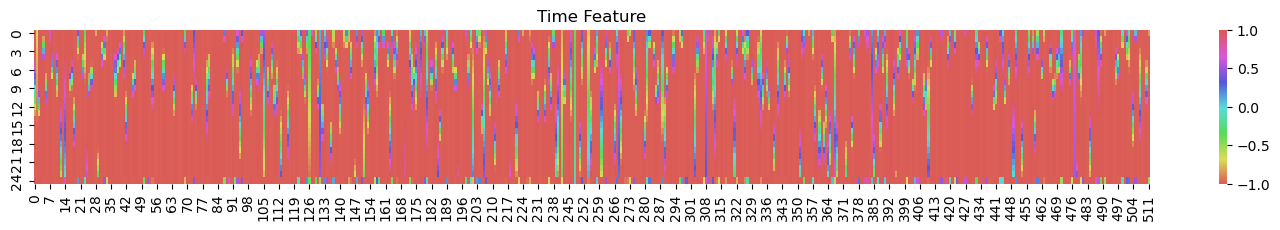

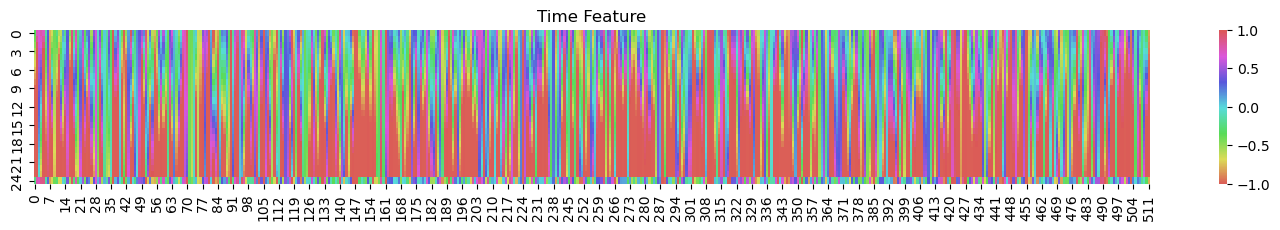

In [13]:
#TimeFeature Embedding
#Embedding Torch
posEmb = epEmbed.TimeFeatureEmbedding(d_model=512)
d = posEmb(XTDate)
fig = plt.figure(figsize=(18,2))
sns.heatmap(d.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');
#Embedding Keras
KTFEmbFct = TimeFeatureEmbedding(d_model=512)
Kdk = KTFEmbFct(XtDate)
fig = plt.figure(figsize=(18,2))
sns.heatmap(Kdk[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');

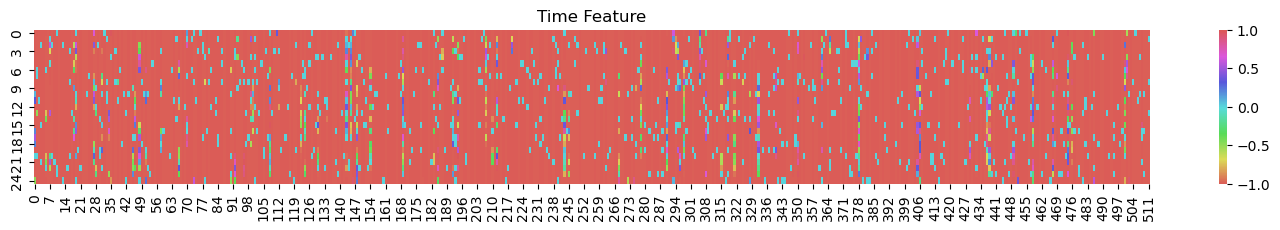

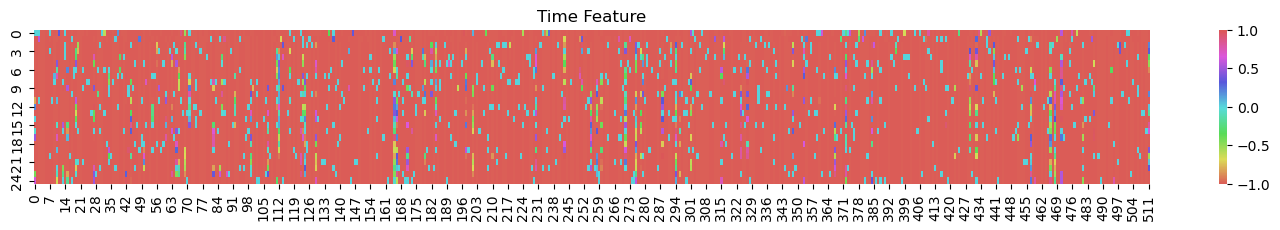

In [4]:
#Final Embedding
d_model = 512
RATE = 0.05
#Embedding Torch
dataTEmb = epEmbed.DataEmbedding(c_in=7,d_model=d_model,dropout=RATE)
d = dataTEmb(XT, XTDate)
fig = plt.figure(figsize=(18,2))
sns.heatmap(d.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');
#Embedding Keras
dataKEmb = DataEmbedding(seq_len=SEQ_LEN, d_model=d_model,rate=RATE)
Kdk = dataKEmb(x=Xt, x_mark=XtDate, training=True)
fig = plt.figure(figsize=(18,2))
sns.heatmap(Kdk[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');

In [ ]:
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.a.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Token');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.b.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('POsitionnal');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.c.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.c.detach()[0]+dataTEmb.b.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional + Time Feature');


In [ ]:
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.a.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Token');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataKEmb.a[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Token');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.b.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('POsitionnal');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataKEmb.b, vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.c.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataKEmb.c[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Time Feature');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.c.detach()[0]+dataTEmb.b.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional + Time Feature');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataKEmb.c[0]+dataKEmb.b, vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional + Time Feature');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.outD.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Embedding return');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataTEmb.a.detach()[0]+dataTEmb.c.detach()[0]+dataTEmb.b.detach()[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Embedding');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataKEmb.outD[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Embedding');
fig = plt.figure(figsize=(18,2))
sns.heatmap(dataKEmb.a[0]+dataKEmb.c[0]+dataKEmb.b, vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Embedding');
